# Streaming training with LSDB datasets

## Open a TESS lightcurve catalog
We'll open the TESS lightcurve catalog from LSDB and filter down the observations
to non-NaN values and ensure that the lightcurves have at least 100 observations.


In [1]:
import lsdb

tess = lsdb.open_catalog("https://data.lsdb.io/hats/tess/tess_lightcurve")

In [2]:
def drop_nans(df):
    # 1. Drop the rows where lightcurve.sap_flux is NaN
    # 2. Also remove all the resulting objects with no lightcurve points remaining
    df["lightcurve.sap_flux"] = df["lightcurve.sap_flux"].astype(float)
    return df.dropna(subset=["lightcurve.sap_flux"]).dropna(subset=["lightcurve"])


tess_filtered_nans = tess.map_partitions(drop_nans)

from nested_pandas.utils import count_nested


def count_points(pts):
    # Asked to count `lightcurve`, this will add a column called `n_lightcurve`
    return count_nested(pts, "lightcurve")


min_observations = 100
tess_filtered_nans = tess_filtered_nans.map_partitions(count_points).query(
    f"n_lightcurve >= {min_observations}"
)

## Hyrax section
Instantiate Hyrax and define the data request using TessLSDBStreamDataset.
This dataset implements two collation functions for the time and sap_flux columns.

In [3]:
from hyrax import Hyrax
from hyrax.datasets import LSDBStreamDataset

h = Hyrax()

In [6]:
LSDBStreamDataset.register_catalog("tess_catalog", tess_filtered_nans)

data_request = {
    "train_stream": {
        "data": {
            "dataset_class": "LightCurveLSDBStreamDataset",
            "data_location": "lsdb://tess_catalog",
            "primary_id_field": "ticid",
            "fields": [
                "lightcurve_time",
                "lightcurve_sap_flux",
                "lightcurve_sap_flux_err",
            ],
        }
    }
}
h.set_config("data_request", data_request)

h.set_config("model.name", "HyraxTs2Vec")

# TESS is single-band, so there is no band column: drop the one-hot block.
# This leaves 3 channels — flux, flux error, log time gap.
h.set_config("data_set.LightCurveLSDBStreamDataset.band_field", False)
h.set_config("data_set.LightCurveLSDBStreamDataset.time_field", "lightcurve_time")
h.set_config("data_set.LightCurveLSDBStreamDataset.flux_field", "lightcurve_sap_flux")
h.set_config("data_set.LightCurveLSDBStreamDataset.flux_err_field", "lightcurve_sap_flux_err")
h.set_config("data_set.LightCurveLSDBStreamDataset.max_sequence_length", 256)

# Training wants an endless stream; the default "catalog" makes exactly one pass and stops.
h.set_config("data_set.LSDBStreamDataset.stream_type", "infinite")
h.set_config("data_set.LSDBStreamDataset.partitions_per_chunk", 4)

# Each TESS object carries thousands of cadences that collate sorts in Python, so 512 makes
# for a slow batch.
h.set_config("data_loader.batch_size", 64)

[2026-08-20 13:55:33,366 hyrax.datasets.lsdb_stream_dataset:WARNING] Replacing the catalog already registered under 'tess_catalog'.


In [7]:
import tqdm
from dask.distributed import Client

batch_counter = 0
MAX_BATCHES = 100

with Client(n_workers=2, threads_per_worker=1, memory_limit="8GB") as client:
    print("Client dashboard:", client.dashboard_link)
    with h.train_stream() as session:
        for batch, metrics in tqdm.tqdm(session):
            batch_counter += 1

            if batch_counter >= MAX_BATCHES:
                break
    client.close()

Client dashboard: http://127.0.0.1:8787/status


[2026-08-20 13:58:12,001 hyrax.models.model_registry:WARNING] Both model and config define an optimizer. Hyrax will use self.optimizer defined in the model.
[2026-08-20 13:58:12,002 hyrax.models.model_registry:INFO] Using self.optimizer defined in model: torch.optim.adamw.AdamW
[2026-08-20 13:58:12,002 hyrax.models.model_registry:WARNING] Both model and config define a criterion. Hyrax will use self.criterion defined in the model.
[2026-08-20 13:58:12,002 hyrax.models.model_registry:INFO] Using self.criterion defined in model: hyrax.models.hyrax_ts2vec.HierarchicalContrastiveLoss
[2026-08-20 13:58:12,003 hyrax.models.model_registry:INFO] Setting model's self.scheduler from config: torch.optim.lr_scheduler.ExponentialLR
with arguments: {'gamma': 1}.
2026-08-20 13:58:12,003 ignite.distributed.auto.auto_dataloader INFO: Use data loader kwargs for dataset '<hyrax.datasets.stre': 
	{'batch_size': None, 'collate_fn': <bound method CollationMixin.collate of <hyrax.datasets.streaming_data_prov

KeyboardInterrupt: 

In [6]:
from hyrax.config_utils import find_most_recent_results_dir

data_request = {
    "infer_stream": {
        "data": {
            "dataset_class": "LightCurveLSDBStreamDataset",
            "data_location": "lsdb://tess_catalog",
            "primary_id_field": "ticid",
            "fields": [
                "lightcurve_time",
                "lightcurve_sap_flux",
                "lightcurve_sap_flux_err",
            ],
        }
    }
}
h.set_config("data_request", data_request)

h.set_config("model.name", "HyraxTs2Vec")

# TESS is single-band, so there is no band column: drop the one-hot block.
# This leaves 3 channels — flux, flux error, log time gap.
h.set_config("data_set.LightCurveLSDBStreamDataset.band_field", False)
h.set_config("data_set.LightCurveLSDBStreamDataset.time_field", "lightcurve_time")
h.set_config("data_set.LightCurveLSDBStreamDataset.flux_field", "lightcurve_sap_flux")
h.set_config("data_set.LightCurveLSDBStreamDataset.flux_err_field", "lightcurve_sap_flux_err")
h.set_config("data_set.LightCurveLSDBStreamDataset.max_sequence_length", 256)

# Training wants an endless stream; the default "catalog" makes exactly one pass and stops.
h.set_config("data_set.LSDBStreamDataset.stream_type", "catalog")
h.set_config("data_set.LSDBStreamDataset.shuffle", False)

h.set_config("infer_stream.save_model_output", True)

# Each TESS object carries thousands of cadences that collate sorts in Python, so 512 makes
# for a slow batch.
h.set_config("data_loader.batch_size", 256)


train_dir = find_most_recent_results_dir(h.config, "train_stream")
h.set_config(
    "infer_stream.model_weights_file",
    str(train_dir / h.config["train_stream"]["weights_filename"]),
)

[2026-08-19 14:34:23,138 hyrax.config_utils:WARNING] Runtime config contains key or section 'infer_stream' which has no default defined. All configuration keys and sections must be defined in /home/drew/code/hyrax/src/hyrax/hyrax_default_config.toml


In [7]:
batch_counter = 0
MAX_BATCHES = 100

with h.infer_stream() as session:
    for batch, metrics in tqdm.tqdm(session):
        batch_counter += 1

        if batch_counter >= MAX_BATCHES:
            break

[2026-08-19 14:34:33,724 hyrax.models.model_registry:WARNING] Both model and config define an optimizer. Hyrax will use self.optimizer defined in the model.
[2026-08-19 14:34:33,725 hyrax.models.model_registry:INFO] Using self.optimizer defined in model: torch.optim.adamw.AdamW
[2026-08-19 14:34:33,725 hyrax.models.model_registry:WARNING] Both model and config define a criterion. Hyrax will use self.criterion defined in the model.
[2026-08-19 14:34:33,725 hyrax.models.model_registry:INFO] Using self.criterion defined in model: hyrax.models.hyrax_ts2vec.HierarchicalContrastiveLoss
[2026-08-19 14:34:33,726 hyrax.models.model_registry:INFO] Setting model's self.scheduler from config: torch.optim.lr_scheduler.ExponentialLR
with arguments: {'gamma': 1}.
2026-08-19 14:34:33,726 ignite.distributed.auto.auto_dataloader INFO: Use data loader kwargs for dataset '<hyrax.datasets.stre': 
	{'batch_size': None, 'collate_fn': <bound method CollationMixin.collate of <hyrax.datasets.streaming_data_prov

In [8]:
infer_dir = find_most_recent_results_dir(h.config, "infer_stream")
umap_results = h.reduce_dimensions(input_dir=infer_dir)

[2026-08-19 14:41:03,600 hyrax.verbs.reduce_dimensions:INFO] Saving reduction results using umap to /home/drew/code/hyrax/docs/pre_executed/results/20260819-144103-umap-l2rm
[2026-08-19 14:41:03,600 hyrax.verbs.reduce_dimensions:INFO] Using most recent inference results dataset for dimensionality reduction.
[2026-08-19 14:41:04,483 hyrax.verbs.reduce_dimensions:INFO] No model_path specified. A new model will be fitted.
[2026-08-19 14:41:04,484 hyrax.verbs.reduction_algorithms.umap:INFO] Fitting the UMAP
[2026-08-19 14:41:11,298 hyrax.verbs.reduce_dimensions:INFO] Saving fitted umap reducer to result directory


Creating lower dimensional representation using UMAP::   0%|          | 0/25 [00:00<?, ?it/s]

[2026-08-19 14:41:50,920 hyrax.datasets.result_dataset:INFO] Optimizing Lance table after 25 batches
[2026-08-19 14:41:50,940 hyrax.datasets.result_dataset:INFO] Lance table optimization complete
[2026-08-19 14:41:50,940 hyrax.verbs.reduce_dimensions:INFO] Finished transforming all data with umap


In [9]:
import numpy as np

# Stack all UMAP embeddings into a single array.
umap_embeddings = np.array([umap_results[i] for i in range(len(umap_results))])
print(f"Shape: {umap_embeddings.shape}  (samples × components)")

Shape: (25600, 2)  (samples × components)


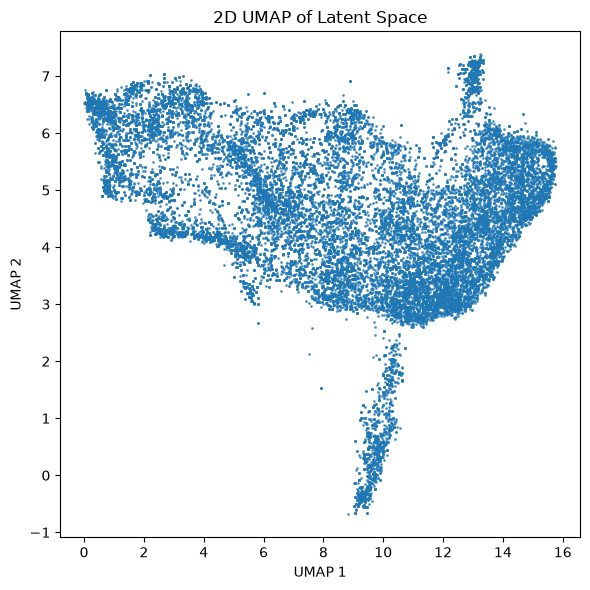

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(umap_embeddings[:, 0], umap_embeddings[:, 1], s=1, alpha=0.7)
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("2D UMAP of Latent Space")
plt.tight_layout()
plt.show()

In [4]:
from importlib.metadata import version

version("hyrax")

'0.9.1.dev9+g3729ab056'

In [1]:
import lsdb

ztf_24 = lsdb.open_catalog("s3://ipac-irsa-ztf/ztf/enhanced/dr24/lc/hats", columns="all")

In [2]:
ztf_24.columns

Index(['_healpix_19', '_healpix_9', 'objectid', 'filterid', 'fieldid', 'rcid',
       'objra', 'objdec', 'nepochs', 'lightcurve', 'Norder', 'Dir', 'Npix'],
      dtype='object')

In [3]:
ztf_24.nested_columns

['lightcurve']

In [4]:
ztf_24["lightcurve"].columns

['hmjd', 'mag', 'magerr', 'clrcoeff', 'catflags']

In [ ]:
ztf_24_no_flags = ztf_24.query("lightcurve_flags == 0")


def drop_nans(df):
    # 1. Drop the rows where lightcurve.sap_flux is NaN
    # 2. Also remove all the resulting objects with no lightcurve points remaining
    df["lightcurve.mag"] = df["lightcurve.mag"].astype(float)
    return df.dropna(subset=["lightcurve.mag"]).dropna(subset=["lightcurve"])


ztf_24_no_flags_filtered_nans = ztf_24_no_flags.map_partitions(drop_nans)

from nested_pandas.utils import count_nested


def count_points(pts):
    # Asked to count `lightcurve`, this will add a column called `n_lightcurve`
    return count_nested(pts, "lightcurve")


min_observations = 100
ztf_24_no_flags_filtered_nans = ztf_24_no_flags_filtered_nans.map_partitions(count_points).query(
    f"n_lightcurve >= {min_observations}"
)